## Downloading Data

In [ ]:
import kagglehub
import os

os.environ['KAGGLEHUB_CACHE'] = "/content/"
path = kagglehub.dataset_download("mikoajkolman/pokemon-images-first-generation17000-files")

100%|██████████| 2.81G/2.81G [00:25<00:00, 117MB/s]

Extracting files...


In [ ]:
import shutil

src_dir = os.path.join('datasets', 'mikoajkolman', 'pokemon-images-first-generation17000-files', 'versions', '1', 'pokemon')
dest_dir = os.path.join('data')

os.makedirs(dest_dir, exist_ok=True)

for folder in os.listdir(src_dir):
    src_path = os.path.join(src_dir, folder)
    dest_path = os.path.join(dest_dir, folder)

    if os.path.isdir(src_path):
        shutil.move(src_path, dest_path)

In [ ]:
!rm -rf datasets

## Defining Transformations

In [ ]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from PIL import Image

class EnsureRGB:
  def __call__(self, img):
    return img.convert("RGB")

simclr_transform = T.Compose([
    EnsureRGB(),
    T.RandomResizedCrop(size=(256, 256), scale=(0.4, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=23),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])


class TwoCropTransform:
  def __init__(self, base_transform):
    self.base_transform = base_transform

  def __call__(self, x):
    return self.base_transform(x), self.base_transform(x),


## Creating Training and Validation Sets

In [ ]:
from torch.utils.data import random_split

dataset = ImageFolder(root = dest_dir, transform = TwoCropTransform(simclr_transform))

subset_size = 5000
subset_dataset, _ = random_split(dataset, [subset_size, len(dataset) - subset_size])

train_size = int(subset_size * 0.8)
val_size = len(subset_dataset) - train_size

train_dataset, val_dataset = random_split(subset_dataset, [train_size, val_size])


## Displaying Augmented Samples

In [ ]:
import matplotlib.pyplot as plt

img1 = subset_dataset[0][0][0]
img1 = img1.permute(1, 2, 0)

img2 = subset_dataset[0][0][1]
img2 = img2.permute(1, 2, 0)

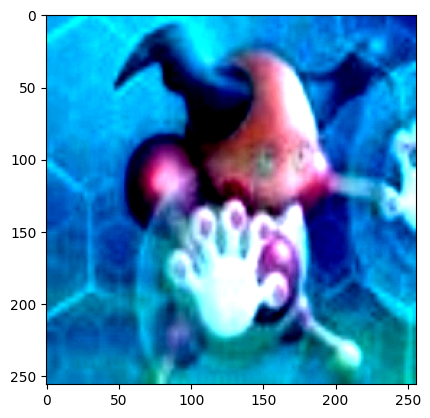

In [ ]:
plt.imshow(img1)


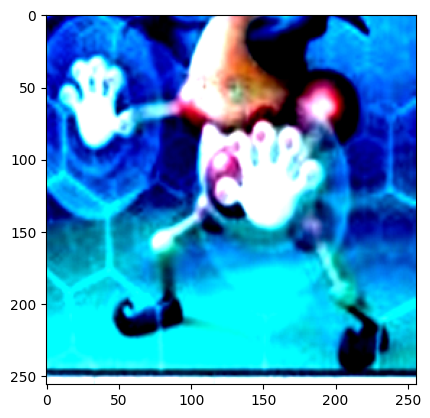

In [ ]:
plt.imshow(img2)

## Creating Dataloaders

In [ ]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size = batch_size,
                          shuffle = True, num_workers = 2, pin_memory = True,
                          drop_last = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = True,
                        num_workers = 2, pin_memory = True, drop_last = True)

## Defining the Contrastive Learning Model

In [ ]:
import torchvision.models as models
import torch.nn as nn

class ContrastiveLearningModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = models.resnet18(progress = True)
    self.encoder.fc = nn.Identity()

    self.projHead = nn.Sequential(
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Linear(256, 128),
              )

  def forward(self, x):
    return self.projHead(self.encoder(x))


## Output Shape Debugging

In [ ]:
import torch

test = torch.unsqueeze(dataset[0][0][0], 0)
model = ContrastiveLearningModel()
model.eval()
with torch.no_grad():
  print(model(test).shape)

torch.Size([1, 128])


## Installing and using NT-Xent Loss

In [ ]:
!pip install pytorch-metric-learning

In [ ]:
import pytorch_metric_learning.losses as losses
import torch.optim as optim

temperature = 0.1
lr = 0.001

loss_fn = losses.NTXentLoss(temperature = temperature)
optimizer = optim.Adam(model.parameters(), lr = lr)

## Configuring Device

In [ ]:
device = 'cpu'
if torch.cuda.is_available():
  device = 'cuda'

model.to(device)
print(device)

cuda


## Training Model

In [ ]:
from tqdm import tqdm

model.train()
num_epochs = 50

for epoch in range(num_epochs):
  total_loss = 0

  for (x1, x2), _ in tqdm(train_loader, desc = f'Epoch {epoch + 1} / {num_epochs}'):
    optimizer.zero_grad()

    x1 = x1.to(device)
    x2 = x2.to(device)

    z1 = model(x1)
    z2 = model(x2)

    z = torch.concat([z1, z2], dim = 0)
    labels = torch.concat([torch.arange(batch_size), torch.arange(batch_size)], dim = 0).to(device)

    loss = loss_fn(z, labels)
    total_loss += loss.item()

    loss.backward()
    optimizer.step()

  if epoch > 0 and epoch % 5 == 0:
    torch.save(model.state_dict(), f'CL_model-{epoch}.pth')

  print(f'Loss after Epoch {epoch + 1}: {total_loss/len(train_loader):.2f}')

## Loading Checkpoint Model for Evaluation

In [ ]:
model = ContrastiveLearningModel()
model.load_state_dict(torch.load('CL_model-15.pth', weights_only = True, map_location = torch.device('cpu')))

<All keys matched successfully>

## Evaluation Function

In [ ]:
def eval(model, data_loader):
  model.eval()
  batch, _ = next(iter(data_loader))
  x1, x2 = batch

  with torch.no_grad():
      z1 = model(x1)
      z2 = model(x2)
      z = torch.cat([z1, z2], dim=0)

  test_image = x1[0].unsqueeze(0)
  z_hat = model(test_image)

  dist = torch.norm(z - z_hat, dim=1)
  knn = dist.topk(3, largest=False)

  return x1, x2, knn.indices


## Plotting k-NN Embeddings Function

In [ ]:
from matplotlib.gridspec import GridSpec

def plot_knn(x1, x2, indices):
  fig = plt.figure(figsize = (16,12))
  gs = GridSpec(2, 3, figure = fig)


  ax = fig.add_subplot(gs[0, :])
  ax.imshow(x1[0].permute(1,2,0))
  ax.set_title("Query Image")
  ax.axis("off")

  for i, val in enumerate(indices):
    ax = fig.add_subplot(gs[1, i])
    ax.axis("off")
    ax.set_title(f'Neighbor {i + 1}')
    if int(val) < 64:
      ax.imshow(x1[int(val)].permute(1,2,0))
    else:
      ax.imshow(x2[int(val) - 64].permute(1,2,0))

  plt.show()

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


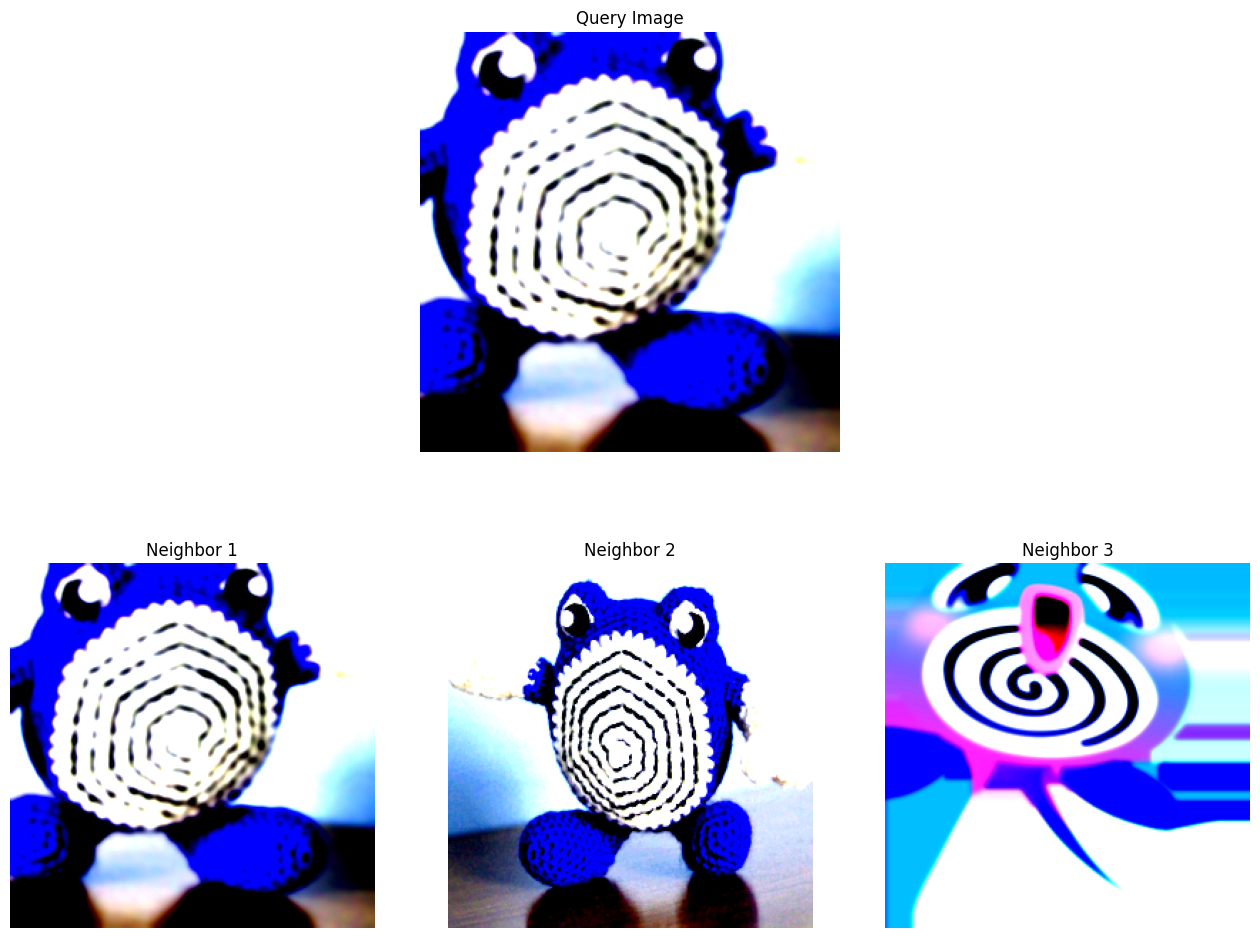

In [ ]:
x1, x2, inds = eval(model, val_loader)
plot_knn(x1, x2, inds)